# 1D Wasserstein Barycenter (Back-and-Forth)

This notebook builds simple 1D measures on a uniform grid, runs the back-and-forth barycenter solver, and plots the input measures and the resulting barycenter.

In [9]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from jax import config
config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from uot.utils.generator_helpers.get_axes import get_axes
from uot.solvers.back_and_forth.barycenter import (
    backnforth_barycenter_sqeuclidean_nd_optimized,
)


In [10]:
# 1D grid
grid_size = 512
axes_np = get_axes(
    dim=1,
    borders=(0.0, 1.0),
    n_points=grid_size,
    cell_discretization="cell-centered",
    use_jax=False,
)
x = axes_np[0]
axes = [jnp.asarray(axes_np[0])]

def normalize_field(field, eps=1e-12):
    field = np.clip(np.asarray(field, dtype=np.float64), 0.0, None)
    total = field.sum()
    return field / total if total > eps else field

def gaussian_1d(x, mean, sigma):
    z = (x - mean) / sigma
    return np.exp(-0.5 * z * z) / (sigma * np.sqrt(2.0 * np.pi))

# Build three 1D measures (normalized discrete masses)
m1 = gaussian_1d(x, mean=0.25, sigma=0.05)
m2 = gaussian_1d(x, mean=0.75, sigma=0.08)
m3 = 0.6 * gaussian_1d(x, mean=0.35, sigma=0.06) + 0.4 * gaussian_1d(x, mean=0.65, sigma=0.03)

m1 = normalize_field(m1)
m2 = normalize_field(m2)
m3 = normalize_field(m3)

measures = jnp.stack([jnp.asarray(m1), jnp.asarray(m2), jnp.asarray(m3)])
weights = jnp.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])

print("Measure sums (discrete):", [float(m.sum()) for m in [m1, m2, m3]])


Measure sums (discrete): [1.0, 1.0, 1.0]


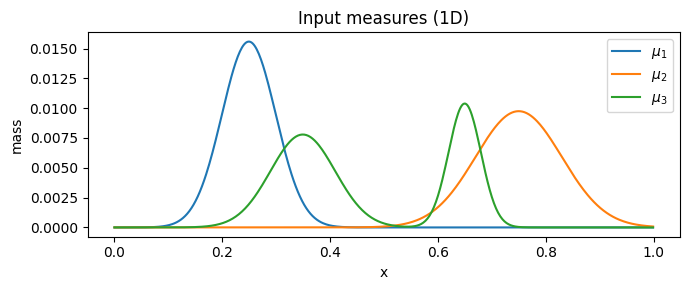

In [11]:
# Plot input measures
plt.figure(figsize=(7, 3))
plt.plot(x, m1, label="$\\mu_1$")
plt.plot(x, m2, label="$\\mu_2$")
plt.plot(x, m3, label="$\\mu_3$")
plt.title("Input measures (1D)")
plt.xlabel("x")
plt.ylabel("mass")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Run back-and-forth barycenter solver
print(f"{type(measures)=}")
print(f"{measures.shape=}")
barycenter, diagnostics = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=weights,
    measures_weights=measures,
    coordinates=axes,
    outer_maxiter=50,
    stopping_tol=5e-3,
    relaxation=1.0,
    transport_stepsize=1.0,
    transport_maxiter=500,
    transport_tol=1e-4,
    transport_error_metric="h1_psi_relative",
)

barycenter_np = np.asarray(barycenter)
print("Barycenter sum (discrete):", float(barycenter_np.sum()))
print("Outer iterations:", int(diagnostics["iterations"]))
print("Final residual:", float(diagnostics["final_residual"]))


type(measures)=<class 'jaxlib._jax.ArrayImpl'>
measures.shape=(3, 512)
Barycenter sum (discrete): 0.9999999999999999
Outer iterations: 50
Final residual: 0.09179498836553002


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/zt/h5ncncv1043cdpswcj8nysgm0000gn/T/ipykernel_3144/3916316683.py:3: S

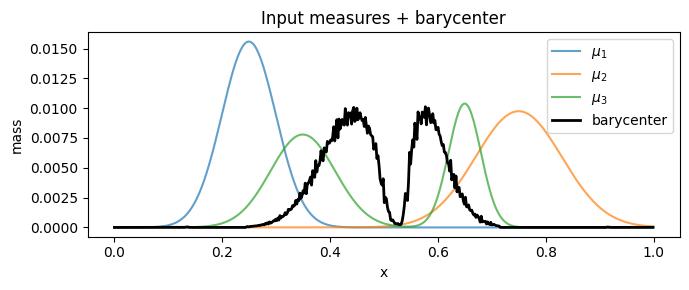

In [13]:
# Plot measures with barycenter
plt.figure(figsize=(7, 3))
plt.plot(x, m1, label="$\mu_1$", alpha=0.7)
plt.plot(x, m2, label="$\mu_2$", alpha=0.7)
plt.plot(x, m3, label="$\mu_3$", alpha=0.7)
plt.plot(x, barycenter_np, label="barycenter", color="black", linewidth=2.0)
plt.title("Input measures + barycenter")
plt.xlabel("x")
plt.ylabel("mass")
plt.legend()
plt.tight_layout()
plt.show()


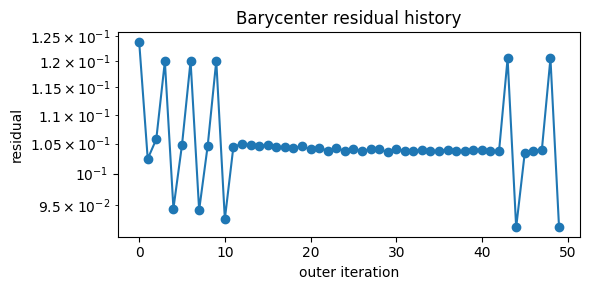

In [14]:
# Diagnostics: residual history (outer loop)
residual_hist = np.asarray(diagnostics["residual_hist"])
plt.figure(figsize=(6, 3))
plt.plot(residual_hist, marker="o")
plt.yscale("log")
plt.title("Barycenter residual history")
plt.xlabel("outer iteration")
plt.ylabel("residual")
plt.tight_layout()
plt.show()


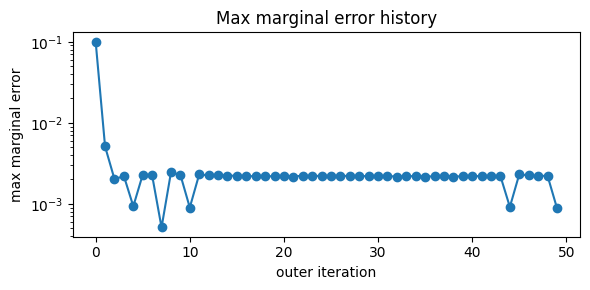

In [15]:
# Diagnostics: marginal error history (outer loop)
marginal_hist = np.asarray(diagnostics["max_marginal_error_hist"])
plt.figure(figsize=(6, 3))
plt.plot(marginal_hist, marker="o")
plt.yscale("log")
plt.title("Max marginal error history")
plt.xlabel("outer iteration")
plt.ylabel("max marginal error")
plt.tight_layout()
plt.show()
